# **Comparative Analysis of SARIMA and SVR for Inflation Rate Forecasting in Bandar Lampung**

### Project Overview
This project compares the performance of **SARIMA** and **SVR** algorithms for forecasting the monthly inflation rate in Bandar Lampung City using data from BPS Lampung Province (2006–2025).

**Data Source:** [BPS Provinsi Lampung](https://lampung.bps.go.id/en/statistics-table/2/MSMy/laju-inflasi-kota-bandar-lampung.html)
> Data was downloaded year-by-year as individual CSV files and merged programmatically.
>

---

**Workflow:**
1. Library & Setup
2. Data Integration
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Stationarity Test (ADF) & ACF/PACF
6. SARIMA Modeling
7. SVR Modeling (with Grid Search)
8. Model Evaluation & Comparison

---
## **1. Library & Setup**

In [1]:
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from pmdarima import auto_arima

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## **2. Data Integration**
Each year's inflation data was downloaded separately from BPS Lampung as individual CSV files.
This step merges all yearly files into a single master dataset and converts the `date` column to a proper datetime format.

In [3]:
path = '/content/drive/My Drive/inflation_rate_bandar_lampung'
all_files = glob.glob(os.path.join(path, "*.csv"))

bulan_list = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

final_list = []

for filename in all_files:
    df = pd.read_csv(filename)
    year_str = "".join(filter(str.isdigit, os.path.basename(filename)))
    if not year_str:
        print(f"Skipping file: {filename}")
        continue

    df_clean = df[df.iloc[:, 0].isin(bulan_list)].copy()
    df_clean = df_clean.iloc[:, [0, 1]]
    df_clean.columns = ['month', 'inflation_rate']
    df_clean['year'] = int(year_str)
    final_list.append(df_clean)

master_df = pd.concat(final_list, ignore_index=True)

master_df['date'] = pd.to_datetime(
    master_df['month'].astype(str) + ' ' + master_df['year'].astype(str),
    format='%B %Y'
)
master_df = master_df.sort_values('date').reset_index(drop=True)

print(master_df[['date', 'month', 'year', 'inflation_rate']].head(6).to_string(index=False))

      date    month  year inflation_rate
2006-01-01  January  2006           3.05
2006-02-01 February  2006          -0.55
2006-03-01    March  2006           0.01
2006-04-01    April  2006           -0.1
2006-05-01      May  2006           0.23
2006-06-01     June  2006            0.3


---
## **3. Data Preprocessing**

In [4]:
# Check data type
print(master_df.dtypes)

month                     object
inflation_rate            object
year                       int64
date              datetime64[ns]
dtype: object


The initial data check revealed taht the inflation_rate column was stored as an object data type. To ensure the data is compatible with SARIMA and SVR algorithms, this column must be converted to numeric. This conversion is a critical preprocessing step to allow for accurate statistical calculations and model training.

In [5]:
# Convert inflation_rate to numeric (handles any non-numeric strings)
master_df['inflation_rate'] = pd.to_numeric(master_df['inflation_rate'], errors='coerce')

# Check missing values
print("Missing Values:")
print(master_df[['date', 'inflation_rate']].isnull().sum())

print("\nData Types:")
print(master_df[['date', 'inflation_rate']].dtypes)

Missing Values:
date              0
inflation_rate    0
dtype: int64

Data Types:
date              datetime64[ns]
inflation_rate           float64
dtype: object


- inflation_rate was has been converted to float64
- No missing values found

---
## **4. Exploratory Data Analysis (EDA)**

In [6]:
# Set up dataframe with datetime index
inflation_df = master_df[['date', 'inflation_rate']].copy()
inflation_df.set_index('date', inplace=True)
inflation_df = inflation_df.loc[~inflation_df.index.duplicated(keep='first')]

# Descriptive statistics
print("Descriptive Statistics:")

Descriptive Statistics:


The descriptive statistics show:
- Mean: ~0.41% monthly inflation -> relatively low and stable on average.
- Std: 0.65% -> ndicating moderate volatility.
- Min: -1.26% -> confirms the city has experienced deflation periods.
- Max: 3.05% -> sharp spikes exist, likely tied to seasonal or shock events.

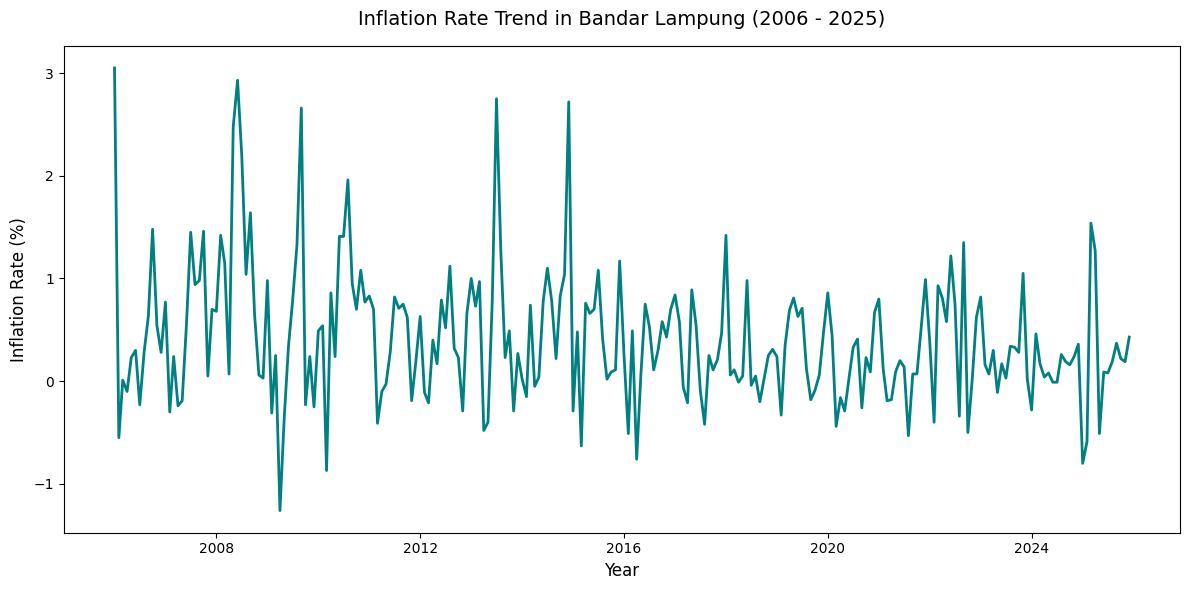

In [7]:
# Plot actual data
plt.figure(figsize=(12, 6))
sns.lineplot(data=master_df, x='date', y='inflation_rate', color='teal', linewidth=2)

plt.title('Inflation Rate Trend in Bandar Lampung (2006 - 2025)', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()

The trend plot illustrates the historical volatility of inflation in Bandar Lampung. While the data fluctuates, there are visible seasonal spikes and occasional extreme values, which justifies the use of both seasonal (SARIMA) and non-linear (SVR) models.

---
## **5. Stationarity Test & ACF/PACF**
SARIMA requires stationary data. The Augmented Dickey-Fuller (ADF) test is used to verify this formally.
- **H₀:** Data has a unit root (non-stationary)
- **H₁:** Data is stationary
> If p-value ≤ 0.05 → reject H₀ → data is stationary

In [8]:
def check_stationarity(data_series):
    result = adfuller(data_series)
    p_value = result[1]

    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {p_value:.4f}')

    # Standard threshold is 0.05
    if p_value <= 0.05:
        print("\nP-Value <= 0.05: Data is stationary.")
    else:
        print("\nP-Value > 0.05: Data is not stationary (need differencing)")

check_stationarity(inflation_df['inflation_rate'])

ADF Statistic: -12.1262
p-value: 0.0000

P-Value <= 0.05: Data is stationary.


The Augmented Dickey-Fuller (ADF) test shows a p-value of 0.0000, which is well below the 0.05 significance level. This confirms that the series is stationary, meaning the mean and variance are stable over time, and the data is ready for SARIMA modeling.

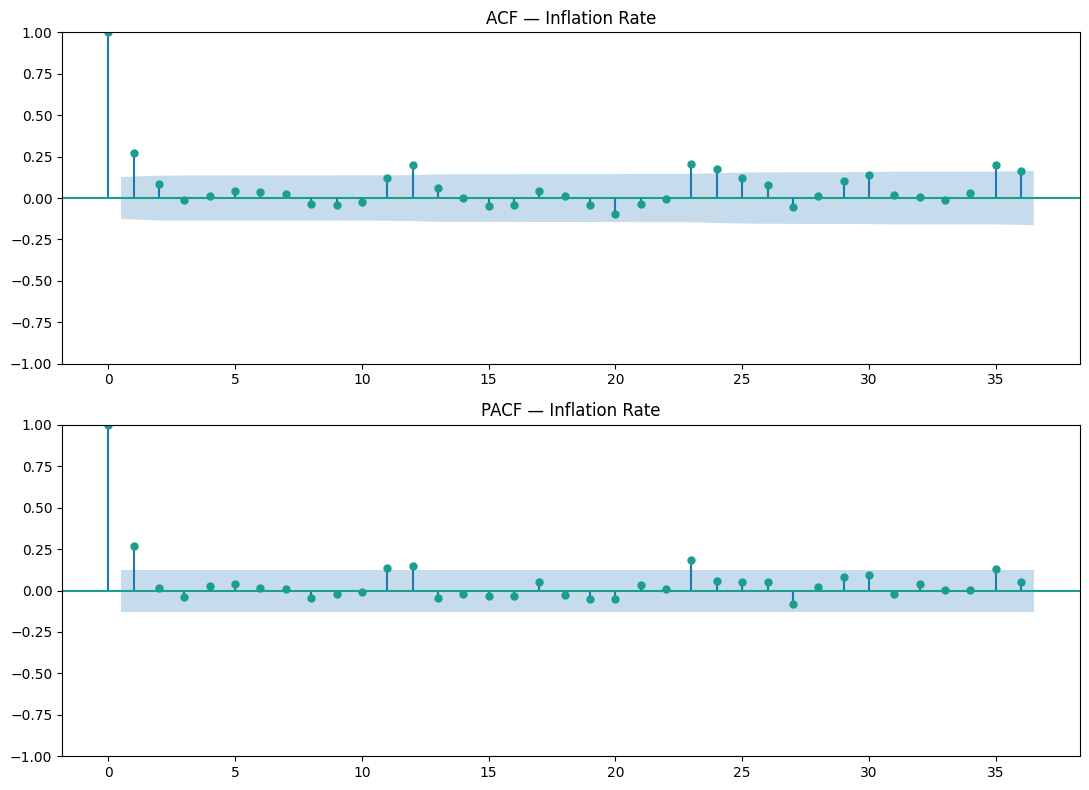

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

# ACF Plot
plot_acf(inflation_df['inflation_rate'], lags=36, ax=ax1, color='#1a9e8f')
ax1.set_title('ACF — Inflation Rate')

# PACF Plot
plot_pacf(inflation_df['inflation_rate'], lags=36, ax=ax2, color='#1a9e8f')
ax2.set_title('PACF — Inflation Rate')

plt.tight_layout()
plt.show()

Interpretation:
- The ACF and PACF plots show a sharp spike at lag 1 in the PACF with an immediate cut-off, along with recurring spikes at lags 12 and 24 in the ACF.
- This indicates an autoregressive component of order 1 and a strong 12-month seasonal pattern.
- D = 1 (seasonal differen cing) is applied to remove the periodic trend, a common
practice even when the original series is stationary at level.
- Based on these observations, the initial candidate model is SARIMA(1,0,1)(1,1,1)12, which will be validated further using Auto ARIMA in the next step.


### Parameter Validation with Auto ARIMA
Use auto_arima to search for the optimal model automatically and validate the manually selected parameters.

In [10]:
# Define train/test split (shared across both models)
train_size = int(len(inflation_df) * 0.8)
date_as_index = inflation_df.index[train_size]

train = inflation_df.iloc[:train_size]
test  = inflation_df.iloc[train_size:]

print(f"Total data   : {len(inflation_df)} months")
print(f"Train period : {len(train)} months")
print(f"Test period  : {len(test)} months")

Total data   : 240 months
Train period : 192 months
Test period  : 48 months


In [11]:
# Auto ARIMA for parameter validation
auto_model = auto_arima(
    train['inflation_rate'],
    seasonal=True, m=12,
    d=0, D=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion='aic',
    stepwise=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"Auto ARIMA best model : {auto_model.order} × {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.4f}")

Auto ARIMA best model : (1, 0, 0) × (0, 1, 1, 12)
AIC: 367.4411


Interpretation:   

Compared to the initial candidate (1,0,1)(1,1,1)12 by manual observation, Auto ARIMA drops the non-seasonal MA (q) and seasonal AR (P) components, as adding them does not produce a sufficient improvement in AIC.
> Akaike Information Criterion (AIC) is a mathematical method for evaluating how well a model fits the data it was generated from, while penalizing for overfitting.

---
## **6. SARIMA Modeling**

In [12]:
model_sarima = SARIMAX(
    train['inflation_rate'].asfreq('MS'),
    order=(1, 0, 1),            # (p, d, q) — non-seasonal
    seasonal_order=(1, 1, 1, 12) # (P, D, Q, s) — seasonal
)

sarima_results = model_sarima.fit(disp=False)
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     inflation_rate   No. Observations:                  192
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -180.863
Date:                            Sun, 22 Mar 2026   AIC                            371.727
Time:                                    10:25:55   BIC                            387.691
Sample:                                01-01-2006   HQIC                           378.200
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5872      0.214      2.743      0.006       0.168       1.007
ma.L1         -0.3547      0.235   

In [13]:
# Ljung-Box residual diagnostic test
lb_test = acorr_ljungbox(sarima_results.resid, lags=[10, 20], return_df=True)
print("Ljung-Box Test:")
print(lb_test)

if (lb_test['lb_pvalue'] > 0.05).all():
    print("\np-value > 0.05 \nResiduals are White Noise.")
else:
    print("\n✗ p-value ≤ 0.05 \nResiduals show autocorrelation.")

Ljung-Box Test:
     lb_stat  lb_pvalue
10  4.666284   0.912328
20  9.107102   0.981633

p-value > 0.05 
Residuals are White Noise.


The Ljung-Box test p-values are above 0.05 for both lag 10 and lag 20.
- Residuals are white noise.
- The SARIMA model is statistically valid for forecasting.

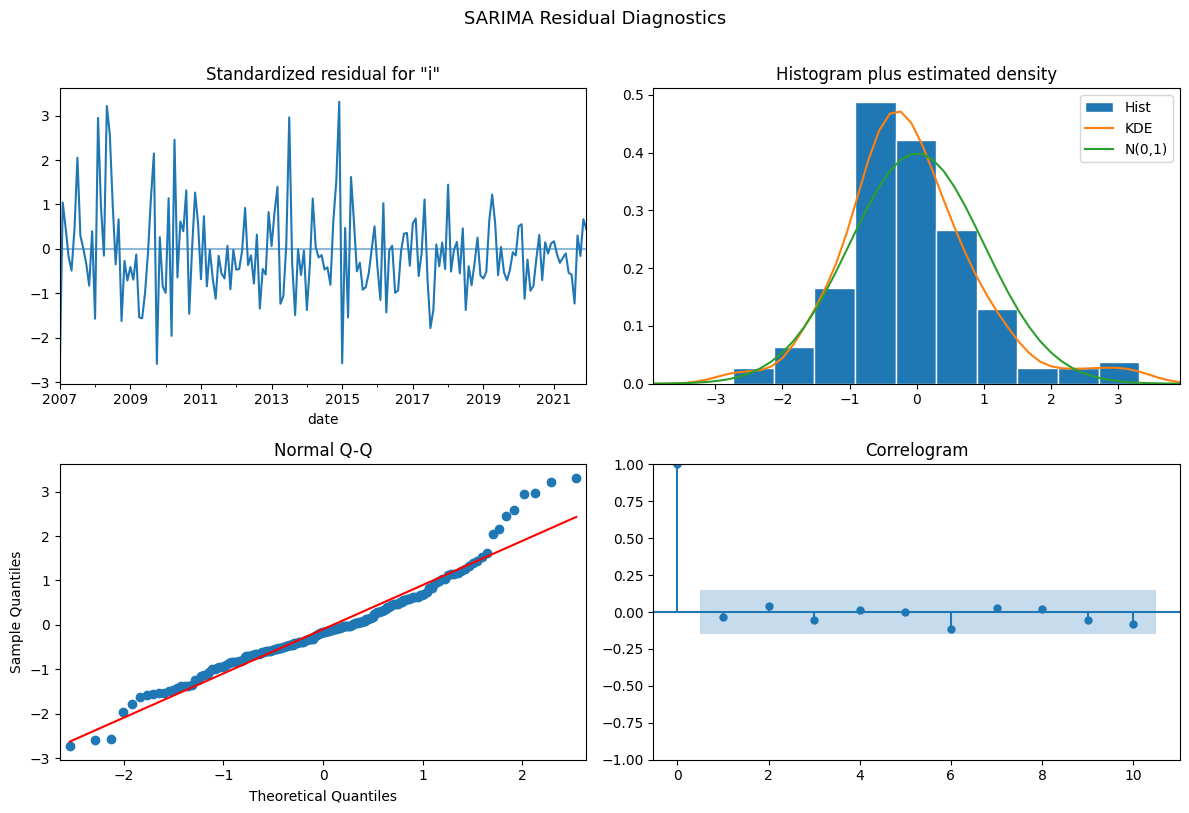

In [14]:
# Residual plot
fig = sarima_results.plot_diagnostics(figsize=(12, 8))
fig.suptitle('SARIMA Residual Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Interpretation:  
- Standardized residuals: Rresiduals behave like white noise.
- Histogram + KDE: Distribution is approximately normal and centered at zero.
- Q-Q plot: Points align closely with the reference line, normality assumption holds.
- Correlogram: No significant spikes means no remaining autocorrelation in residuals.

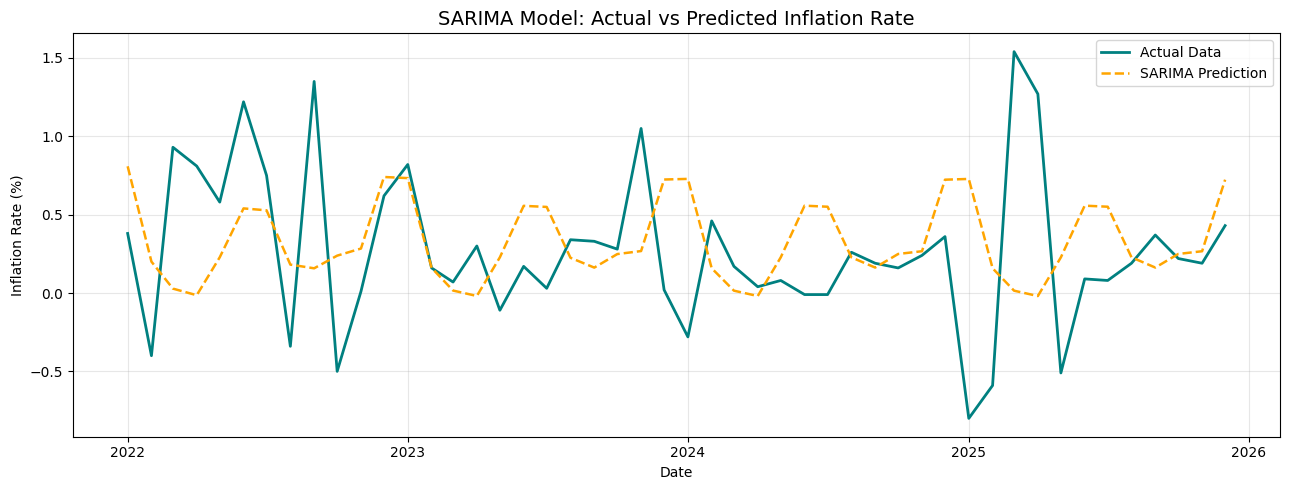

In [15]:
# Forecast on test set
forecast_obj  = sarima_results.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int()

# Plot
plt.figure(figsize=(13, 5))

plt.plot(test.index, test['inflation_rate'],
         label='Actual Data', color='teal', linewidth=2)
plt.plot(test.index, forecast_mean,
         label='SARIMA Prediction', color='orange', linestyle='--', linewidth=1.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

plt.title('SARIMA Model: Actual vs Predicted Inflation Rate', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Interpretation:  
- SARIMA produces smooth, stable forecasts, oscillating around the 0-0.5% range.
- The model underestimates extreme spikes
- It cannot predict negative values (deflation) that appear in the actual data.
- The 95% confidence interval is reasonably tight, indicating the model has low uncertainty on average, but the actual data frequently falls outside this band during volatile periods.

---
## **7. SVR Modeling (with Grid Search)**

In [16]:
# Build lag features
svr_df = inflation_df.copy()

for i in [1, 2, 3, 12]:
    svr_df[f'lag_{i}'] = svr_df['inflation_rate'].shift(i)

svr_df.dropna(inplace=True)

print(svr_df.head(3).to_string())
print(f"\nSVR dataset: {len(svr_df)} rows")

            inflation_rate  lag_1  lag_2  lag_3  lag_12
date                                                   
2007-01-01            0.77   0.28   0.54   1.48    3.05
2007-02-01           -0.30   0.77   0.28   0.54   -0.55
2007-03-01            0.24  -0.30   0.77   0.28    0.01

SVR dataset: 228 rows


Interpretation:  
SVR has no built-in mechanism to process time ordering, so historical information is manually introduced as lag features:
- lag_1, lag_2, lag_3: short-term autoregressive memory
- lag_12: annual seasonal pattern, it is equivalent to the seasonal component in SARIMA

Rows with NaN (from shifting) are removed. The resulting dataset still covers the same test period.

In [17]:
# Split by date
features = ['lag_1', 'lag_2', 'lag_3', 'lag_12']

X = svr_df[features]
y = svr_df['inflation_rate']

X_train = X[X.index < date_as_index]
X_test  = X[X.index >= date_as_index]
y_train = y[y.index < date_as_index]
y_test  = y[y.index >= date_as_index]

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")


Train : 180 samples
Test  : 48 samples


In [18]:
# Feature scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

StandardScaler is applied to features and target:
- Fit only on training data to prevent data leakage.
- The same scaler is used to transform the test set.
- The target y is also scaled so SVR can learn efficiently
> predictions are inverse-transformed back to the original scale.

In [19]:
# Grid Search
param_grid = {
    'C'      : [1, 10, 100],
    'gamma'  : [0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error', # metric to minimize prediction error
    n_jobs=-1                         # use all CPU cores for faster calculation
)

grid_search.fit(X_train_scaled, y_train_scaled)

best_params = grid_search.best_params_
best_score  = -grid_search.best_score_

print(f"Best Parameters     : {best_params}")
print(f"Best CV MSE         : {best_score:.4f}  (in standardized scale)")

Best Parameters     : {'C': 1, 'epsilon': 0.5, 'gamma': 0.1}
Best CV MSE         : 0.7205  (in standardized scale)


- The Best CV MSE is expressed in the standardized (scaled) space, not the original % inflation scale.
- Parameters are searched on a logarithmic scale to efficiently compare distinctly different model behaviors.

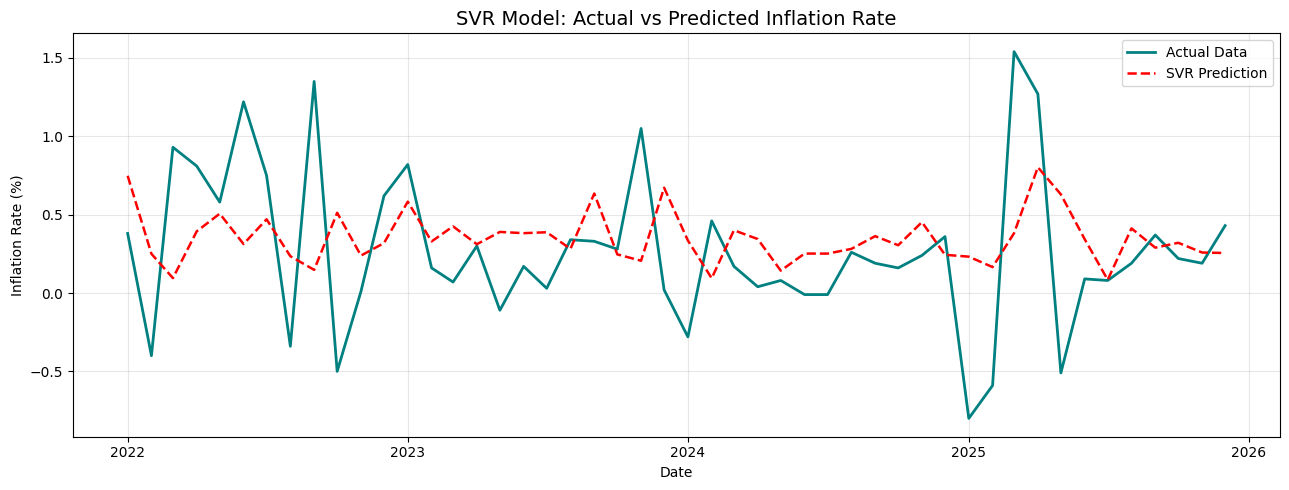

In [20]:
# Train with best parameters
model_svr = SVR(kernel='rbf', **best_params)
model_svr.fit(X_train_scaled, y_train_scaled)

# Predict and inverse-transform
preds_scaled = model_svr.predict(X_test_scaled)
preds_final  = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

# Plot
plt.figure(figsize=(13, 5))

plt.plot(y_test.index, y_test.values,
         label='Actual Data', color='teal', linewidth=2)
plt.plot(y_test.index, preds_final,
         label='SVR Prediction', color='red', linestyle='--', linewidth=1.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

plt.title('SVR Model: Actual vs Predicted Inflation Rate', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Interpretation:  
- SVR produces more dynamic predictions that follow the direction of movement (up/down) more closely than SARIMA.
- It partially captures the extreme spike in early 2025, outperforming SARIMA at that point.
- Some response lag is visible at certain turning points
- SVR can predict negative values (deflation) unlike SARIMA, but still underestimates the magnitude of sharp deflation events.

---
## **8. Model Evaluation & Comparison**



In [21]:
# SARIMA
sarima_rmse = np.sqrt(mean_squared_error(test['inflation_rate'], forecast_mean))
sarima_mape = mean_absolute_percentage_error(test['inflation_rate'], forecast_mean) * 100

# SVR
svr_rmse = np.sqrt(mean_squared_error(y_test, preds_final))
svr_mape = mean_absolute_percentage_error(y_test, preds_final) * 100

# Comparison table
comparison_data = {
    'Metric': ['RMSE', 'MAPE (%)'],
    'SARIMA': [round(sarima_rmse, 4), f"{sarima_mape:.2f}%"],
    'SVR': [round(svr_rmse, 4), f"{svr_mape:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)

print("METRIC EVALUATION: \n")
print(comparison_df.to_string(index=False))


METRIC EVALUATION: 

  Metric  SARIMA     SVR
    RMSE  0.5905  0.5146
MAPE (%) 504.10% 357.47%


Interpretation:  
MAPE works by dividing the error by the actual value. The problem is that Bandar Lampung's inflation data contains many near-zero values (e.g., 0.01, 0.03) and negative values (deflation such as -0.8, -0.01). When the actual value is close to zero, a single data point can produce an extreme percentage error.

### **Solution:**
**Use SMAPE (Symmetric MAPE) as a replacement.**

> Why SMAPE instead of MAPE?  

Standard MAPE is defined as:

$$\text{MAPE} = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%$$

This formula has a critical flaw when y_i is near zero or negative  the division produces disproportionately large values.
Inflation data contains both near-zero values (e.g., `0.01%`) and negative values (deflation), so that making MAPE unreliable.

**SMAPE (Symmetric MAPE)** resolves this by dividing by the *average* of actual and predicted absolute values:

$$\text{SMAPE} = \frac{1}{n} \sum \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2} \times 100\%$$

SMAPE is bounded between 0% and 200%, and is robust to near-zero and negative values.

In [22]:
# Solution
def smape(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    denom = (np.abs(actual) + np.abs(predicted)) / 2
    mask  = denom != 0
    return np.mean(np.abs(actual[mask] - predicted[mask]) / denom[mask]) * 100

# SARIMA
sarima_rmse  = np.sqrt(mean_squared_error(test['inflation_rate'], forecast_mean))
sarima_smape = smape(test['inflation_rate'].values, forecast_mean.values)

# SVR
svr_rmse  = np.sqrt(mean_squared_error(y_test, preds_final))
svr_smape = smape(y_test.values, preds_final)

# Comparison table
comparison_data = {
    'Metric' : ['RMSE', 'SMAPE (%)'],
    'SARIMA' : [round(sarima_rmse, 4),  f"{sarima_smape:.2f}%"],
    'SVR'    : [round(svr_rmse, 4),     f"{svr_smape:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)

print("METRIC EVALUATION: \n")
print(comparison_df.to_string(index=False))

METRIC EVALUATION: 

   Metric  SARIMA     SVR
     RMSE  0.5905  0.5146
SMAPE (%) 118.10% 103.43%


Interpretation:

- RMSE: SVR achives 0.5146 compared to SARIMA's 0.5905, it means SVR's average deviation from the actual values is smaller.
- SMAPE: SVR also performs better at 103.43% versus SARIMA's 118.10%.
- Both SMAPE values are relatively high, this does not indicate overfitting. It reflects the inherent characteristic of inflation data.
> there are many data near zero values and extreme fluctuation that are difficult for univariate model to capture.


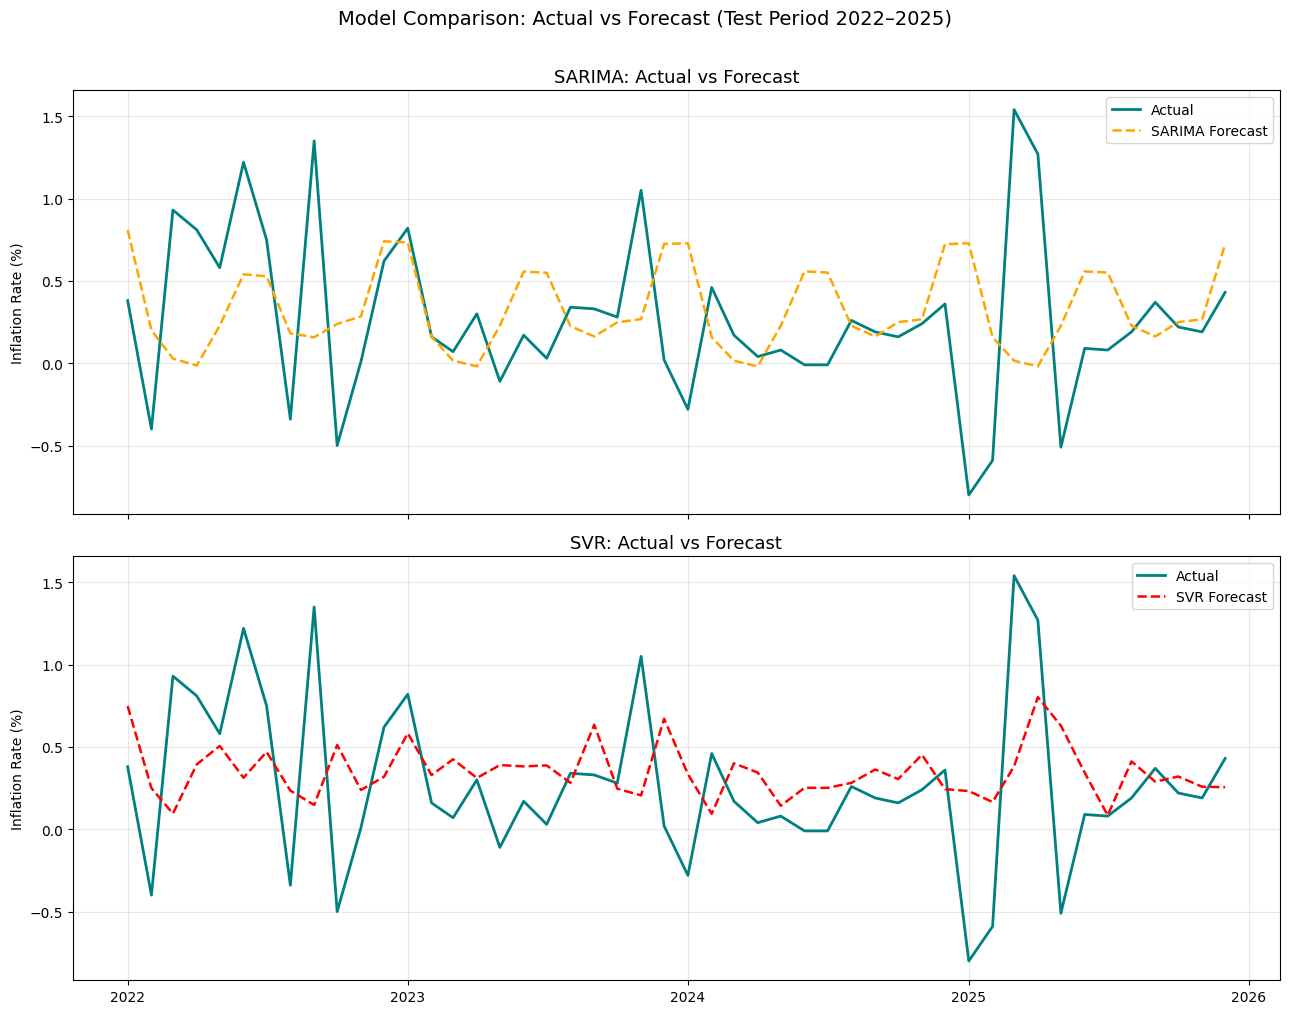

In [23]:
# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

plt.sca(ax1)
plt.plot(test.index, test['inflation_rate'], label='Actual', color='teal', linewidth=2)
plt.plot(test.index, forecast_mean, label='SARIMA Forecast', color='orange', linestyle='--', linewidth=1.8)
plt.title('SARIMA: Actual vs Forecast', fontsize=13)
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.sca(ax2)
plt.plot(y_test.index, y_test.values, label='Actual', color='teal', linewidth=2)
plt.plot(y_test.index, preds_final, label='SVR Forecast', color='red', linestyle='--', linewidth=1.8)
plt.title('SVR: Actual vs Forecast', fontsize=13)
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

fig.suptitle('Model Comparison: Actual vs Forecast (Test Period 2022–2025)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## **Conclusion**  

- Bandar Lampung's monthly inflation data is stationary with a strong 12-month
seasonal pattern, alongside extreme fluctuations driven by economic events such as post-pandemic price surges and deflation periods.
- SARIMA produces stable but overly smooth predictions — suitable for medium-term trends, but unable to capture extreme spikes and deflation.
- SVR with RBF kernel and Grid Search optimization proves more adaptive to non-linear patterns, achieving better performance on both evaluation metrics.
- Based on RMSE (0.5146 vs 0.5905) and SMAPE (103.43% vs 118.10%), **SVR is the more optimal model** for forecasting the monthly inflation rate of Bandar Lampung City.